# Synthetic Survival Data With Controlled Signal

This notebook demonstrates how to use `torchsurv.tools.make_synthetic_data` to create Cox-style synthetic survival datasets with controllable signal strength.

The goal is to show a practical failure mode from [issue #154](https://github.com/Novartis/torchsurv/issues/154): when the loss does not improve, the problem can come from the data having weak or no learnable survival signal, not from `TorchSurv` itself.

Here `rho` controls how much of the true latent risk is explained by the covariates:

- `rho = 1.0`: very easy, features fully determine the latent risk
- `rho = 0.0`: very hard, features contain no risk information
- intermediate values: gradually harder learning problems


In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn

from torchsurv.loss.cox import neg_partial_log_likelihood
from torchsurv.metrics.cindex import ConcordanceIndex
from torchsurv.tools import make_synthetic_data

torch.manual_seed(7)

/Users/corolth1/anaconda3/envs/torchsurv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /Users/corolth1/anaconda3/envs/torchsurv/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
def split_batch(batch, train_fraction: float = 0.8):
    n = batch["x"].shape[0]
    n_train = int(train_fraction * n)
    permutation = torch.randperm(n)
    train_index = permutation[:n_train]
    val_index = permutation[n_train:]

    train_batch = {
        key: value[train_index] if value.ndim > 0 and value.shape[0] == n else value for key, value in batch.items()
    }
    val_batch = {
        key: value[val_index] if value.ndim > 0 and value.shape[0] == n else value for key, value in batch.items()
    }
    return train_batch, val_batch


def train_cox_model(train_batch, val_batch, *, epochs: int = 120, lr: float = 0.05):
    model = nn.Linear(train_batch["x"].shape[1], 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    cindex = ConcordanceIndex()

    train_losses = []
    val_cindices = []

    for _ in range(epochs):
        optimizer.zero_grad()
        loss = neg_partial_log_likelihood(model(train_batch["x"]), train_batch["event"], train_batch["time"])
        loss.backward()
        optimizer.step()
        train_losses.append(loss.detach())

        with torch.no_grad():
            risk_val = model(val_batch["x"]).squeeze(-1)
            val_cindices.append(cindex(risk_val, val_batch["event"], val_batch["time"], instate=False).detach())

    return model, torch.stack(train_losses), torch.stack(val_cindices)

In [3]:
def run_experiment(rho: float, *, n: int = 512, m: int = 8, seed: int = 7):
    batch = make_synthetic_data(n=n, m=m, rho=rho, censoring_rate=0.3, seed=seed)
    train_batch, val_batch = split_batch(batch)
    _, train_losses, val_cindices = train_cox_model(train_batch, val_batch)
    return {
        "rho": rho,
        "train_losses": train_losses,
        "val_cindices": val_cindices,
        "censoring_rate": (~batch["event"]).float().mean(),
    }

In [4]:
rhos = [1.0, 0.75, 0.5, 0.25, 0.0]
results = [run_experiment(rho) for rho in rhos]

summary = {
    result["rho"]: {
        "final_train_loss": float(result["train_losses"][-1]),
        "final_val_cindex": float(result["val_cindices"][-1]),
        "observed_censoring_rate": float(result["censoring_rate"]),
    }
    for result in results
}
summary

{1.0: {'final_train_loss': 4.810527324676514,
  'final_val_cindex': 0.7056451439857483,
  'observed_censoring_rate': 0.298828125},
 0.75: {'final_train_loss': 4.89111328125,
  'final_val_cindex': 0.7180487513542175,
  'observed_censoring_rate': 0.298828125},
 0.5: {'final_train_loss': 4.932214260101318,
  'final_val_cindex': 0.6513043642044067,
  'observed_censoring_rate': 0.298828125},
 0.25: {'final_train_loss': 5.0428667068481445,
  'final_val_cindex': 0.6064745783805847,
  'observed_censoring_rate': 0.298828125},
 0.0: {'final_train_loss': 5.140138149261475,
  'final_val_cindex': 0.4678764045238495,
  'observed_censoring_rate': 0.298828125}}

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for result in results:
    normalized_loss = result["train_losses"] / result["train_losses"][0]
    axes[0].plot(normalized_loss.numpy(), label=f"rho={result['rho']:.2f}")
    axes[1].plot(result["val_cindices"].numpy(), label=f"rho={result['rho']:.2f}")

axes[0].set_title("Normalized Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss / initial loss")
axes[0].set_yscale("log")

axes[1].set_title("Validation C-index")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("C-index")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)

for axis in axes:
    axis.legend()

plt.tight_layout()

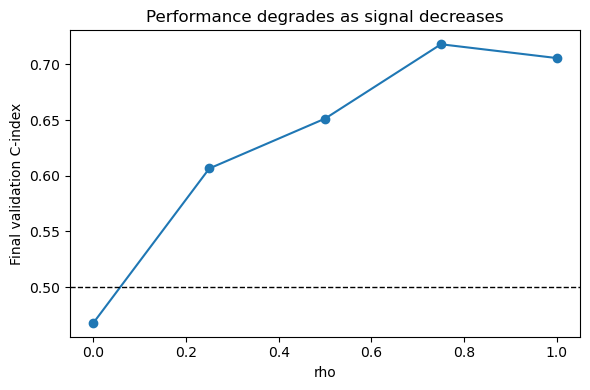

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rhos, [summary[rho]["final_val_cindex"] for rho in rhos], marker="o")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("rho")
ax.set_ylabel("Final validation C-index")
ax.set_title("Performance degrades as signal decreases")
plt.tight_layout()

## Interpretation

This benchmark is meant to separate two cases:

1. When `rho` is high, a simple linear Cox model should reduce the loss and reach a validation C-index clearly above random.
2. When `rho` is near zero, the same training loop, loss function, and optimization setup can plateau near random ranking because the covariates no longer contain usable signal.

That is the practical point of the synthetic benchmark: if a real experiment does not improve, it may reflect a weak data-generating signal rather than a bug in `TorchSurv`.
